# Manuscript figures — DARCLOS-TEMPO paper

Generates the three data figures for the manuscript (Overleaf project `TEMPO_shadows`):

| Manuscript label | Output file | Source data |
|---|---|---|
| `fig:granule-morning` | `docs/paper/figures/fig_granule_morning.pdf` | Granule S003G05, 2025-09-09 12:52 UTC (local `data/raw_l1` + `data/raw_l2_v4`) |
| `fig:granule-afternoon` | `docs/paper/figures/fig_granule_afternoon.pdf` | Granule S014G02, 2025-09-09 23:12 UTC (local `data/raw_l1` + `data/raw_l2_v4`) |
| `fig:scan-mosaic` | `docs/paper/figures/fig_scan_S004.pdf` | Scan S004, 2025-09-17, pipeline outputs in `results_scan_scan/2025/09/17/` (run with the ECEF k-d-tree code, commit `a31bb72`) |

The pipeline schematic (`fig:pipeline`) is drawn separately in draw.io, not here.

This notebook **only orchestrates and plots**: all algorithm logic is imported unmodified
from `scripts/shadows.py` and `scripts/io_utils.py`, with parameters read from
`configs/day_example.yaml`. Per-granule masks are recomputed in memory with
`compute_masks` (identical to the production pipeline). Runs top-to-bottom.

**Explicit parameter deviation:** granule S014G02 has 10.4 % of cloud-source pixels
without a valid cloud height, which exceeds the default guard
`max_drop_frac = 0.10`; it is processed with `max_drop_frac = 0.15`
(inside the documented 0.10–0.30 range, Table 1 of the manuscript). This guard only
controls the fail-loudly threshold — it does not alter any mask value.

In [1]:
import subprocess
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import yaml

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO / "scripts"))
from io_utils import find_matching_l2_file, load_l1b, load_l2, orient_2d
from shadows import (ShadowParams, compute_heights_vectorized, compute_masks,
                     project_shadow_coords_vectorized)

# --- Provenance: log code version and full algorithm configuration -----------
GIT_HASH = subprocess.run(["git", "rev-parse", "--short", "HEAD"], cwd=REPO,
                          capture_output=True, text=True).stdout.strip()
CFG = yaml.safe_load(open(REPO / "configs" / "day_example.yaml"))
ALGO_KEYS = ("cloud_threshold", "shadow_threshold", "safety_factor_c", "h_scale_m",
             "h_cap_m", "max_drop_frac", "m_earth", "n_earth", "l1_band",
             "apply_gamma", "gamma")
print(f"git hash        : {GIT_HASH}")
print(f"python          : {sys.version.split()[0]}")
for k in ALGO_KEYS:
    print(f"{k:16s}: {CFG[k]}")

FIG_DIR = REPO / "docs" / "paper" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Okabe-Ito colorblind-safe palette
C_CLOUD, C_PCSF, C_ACSF = "#56B4E9", "#E69F00", "#D55E00"

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "figure.dpi": 110,
    "savefig.dpi": 300,
})

git hash        : 6cd3a78
python          : 3.13.7
cloud_threshold : 0.3
shadow_threshold: 0.05
safety_factor_c : 0.5
h_scale_m       : 8500.0
h_cap_m         : 16000.0
max_drop_frac   : 0.1
m_earth         : 6378137.0
n_earth         : 6378137.0
l1_band         : band_290_490_nm
apply_gamma     : True
gamma           : 0.4


## Per-granule figures (`fig:granule-morning`, `fig:granule-afternoon`)

Both granules cover the same central-US longitude band (≈ 99–88° W), observed at
12:52 UTC (early morning, solar azimuth ≈ +92°, sun in the east) and 23:12 UTC
(late afternoon, solar azimuth ≈ −93°, sun in the west). Shadows must therefore
project in opposite longitudinal directions between the two figures — this is
checked quantitatively below.

In [2]:
def run_granule(l1_name: str, max_drop_frac: float) -> dict:
    """Load one local L1B/L2 granule pair and run the production algorithm.

    Parameters
    ----------
    l1_name : str
        L1B filename inside ``data/raw_l1``.
    max_drop_frac : float
        Fail-loudly guard passed to :class:`ShadowParams` (see header note).

    Returns
    -------
    dict with the raw L1/L2 arrays, the three boolean masks
    ``(mirror_step, xtrack)``, the diagnostics dict, and the parameters used.
    """
    l1_path = REPO / "data" / "raw_l1" / l1_name
    l2_path = find_matching_l2_file(str(l1_path), str(REPO / "data" / "raw_l2_v4"), "V04")
    if l2_path is None:
        raise FileNotFoundError(f"No matching V04 L2 granule for {l1_name}")
    params = ShadowParams(
        cloud_threshold=CFG["cloud_threshold"], shadow_threshold=CFG["shadow_threshold"],
        safety_factor_c=CFG["safety_factor_c"], h_scale_m=CFG["h_scale_m"],
        h_cap_m=CFG["h_cap_m"], max_drop_frac=max_drop_frac,
        m_earth=CFG["m_earth"], n_earth=CFG["n_earth"])
    l1 = load_l1b(str(l1_path), CFG["l1_band"])
    l2 = load_l2(str(l2_path))
    cloud, pcsf, acsf, diag = compute_masks(
        lat=l2["lat"], lon=l2["lon"], cloud_fraction=l2["cloud_fraction"],
        cloud_pressure=l2["cloud_pressure"], surface_pressure=l2["surface_pressure"],
        terrain_height=l2["terrain_height"], cth_l1b=l1["cth"],
        sza=l1["sza"], saa=l1["saa"], vza=l1["vza"], vaa=l1["vaa"], params=params)
    assert cloud.shape == l2["lat"].shape, "mask/grid shape mismatch"
    assert not np.any(acsf & ~pcsf), "oracle failed: ACSF must be a subset of PCSF"
    n = cloud.size
    print(f"{l1_name}")
    print(f"  grid {cloud.shape}   cloud {cloud.sum():6d} ({100*cloud.sum()/n:4.1f} %)   "
          f"PCSF {pcsf.sum():6d} ({100*pcsf.sum()/n:4.1f} %)   "
          f"ACSF {acsf.sum():6d} ({100*acsf.sum()/n:4.1f} %)")
    print(f"  diag {diag}   ACSF/cloud-source = {100*acsf.sum()/max(diag['n_source'],1):.1f} %")
    return {"l1": l1, "l2": l2, "cloud": cloud, "pcsf": pcsf, "acsf": acsf,
            "diag": diag, "params": params, "name": l1_name}


morning   = run_granule("TEMPO_RAD_L1_V04_20250909T125205Z_S003G05.nc", CFG["max_drop_frac"])
afternoon = run_granule("TEMPO_RAD_L1_V04_20250909T231218Z_S014G02.nc", 0.15)

TEMPO_RAD_L1_V04_20250909T125205Z_S003G05.nc
  grid (131, 2048)   cloud  89437 (33.3 %)   PCSF  32032 (11.9 %)   ACSF  12671 ( 4.7 %)
  diag {'n_source': 89437, 'n_dropped_height': 5917, 'n_dropped_angles': 0}   ACSF/cloud-source = 14.2 %


TEMPO_RAD_L1_V04_20250909T231218Z_S014G02.nc
  grid (132, 2048)   cloud  77715 (28.7 %)   PCSF  37640 (13.9 %)   ACSF  13229 ( 4.9 %)
  diag {'n_source': 77715, 'n_dropped_height': 8095, 'n_dropped_angles': 0}   ACSF/cloud-source = 17.0 %


In [3]:
def shadow_direction_oracle(res: dict) -> float:
    """Mean longitudinal shadow displacement (degrees east) over all source pixels.

    Physical sanity bound: the shadow must fall on the side opposite the sun.
    With the geographic azimuth convention (0° = North, positive clockwise,
    pointing toward the sun), solar azimuth > 0 (sun in the east) requires a
    westward mean displacement (negative), and vice versa.
    """
    l1, l2, p = res["l1"], res["l2"], res["params"]
    h = compute_heights_vectorized(l1["cth"], l2["cloud_pressure"],
                                   l2["surface_pressure"], l2["terrain_height"], p)
    ii, jj = np.where(res["cloud"] & np.isfinite(h))
    sh_lat, sh_lon = project_shadow_coords_vectorized(
        l2["lat"], l2["lon"], h, l2["terrain_height"],
        l1["sza"], l1["saa"], l1["vza"], l1["vaa"], ii, jj, p)
    return float(np.nanmean(sh_lon - l2["lon"][ii, jj]))


for res in (morning, afternoon):
    saa = float(np.nanmedian(res["l1"]["saa"]))
    dlon = shadow_direction_oracle(res)
    side = "west" if dlon < 0 else "east"
    print(f"{res['name']}: median SAA = {saa:+7.1f}°  mean shadow dlon = {dlon:+.3f}° ({side}ward)")
    assert (saa > 0) == (dlon < 0), (
        f"oracle failed: sun azimuth {saa:+.1f}° but mean shadow displacement {dlon:+.3f}°")
print("Shadow-direction oracle passed for both granules.")

TEMPO_RAD_L1_V04_20250909T125205Z_S003G05.nc: median SAA =   +92.2°  mean shadow dlon = -0.406° (westward)
TEMPO_RAD_L1_V04_20250909T231218Z_S014G02.nc: median SAA =   -92.9°  mean shadow dlon = +0.492° (eastward)
Shadow-direction oracle passed for both granules.


wrote /Users/maperezc/Downloads/TEMPO/preprocess_shadows/docs/paper/figures/fig_granule_morning.pdf


wrote /Users/maperezc/Downloads/TEMPO/preprocess_shadows/docs/paper/figures/fig_granule_afternoon.pdf


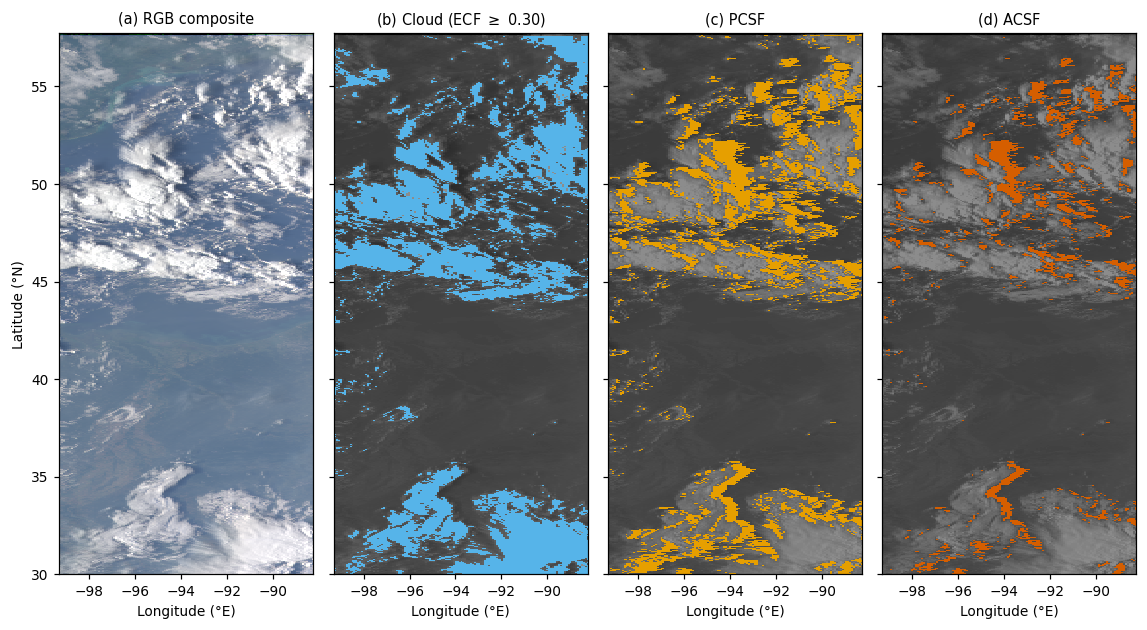

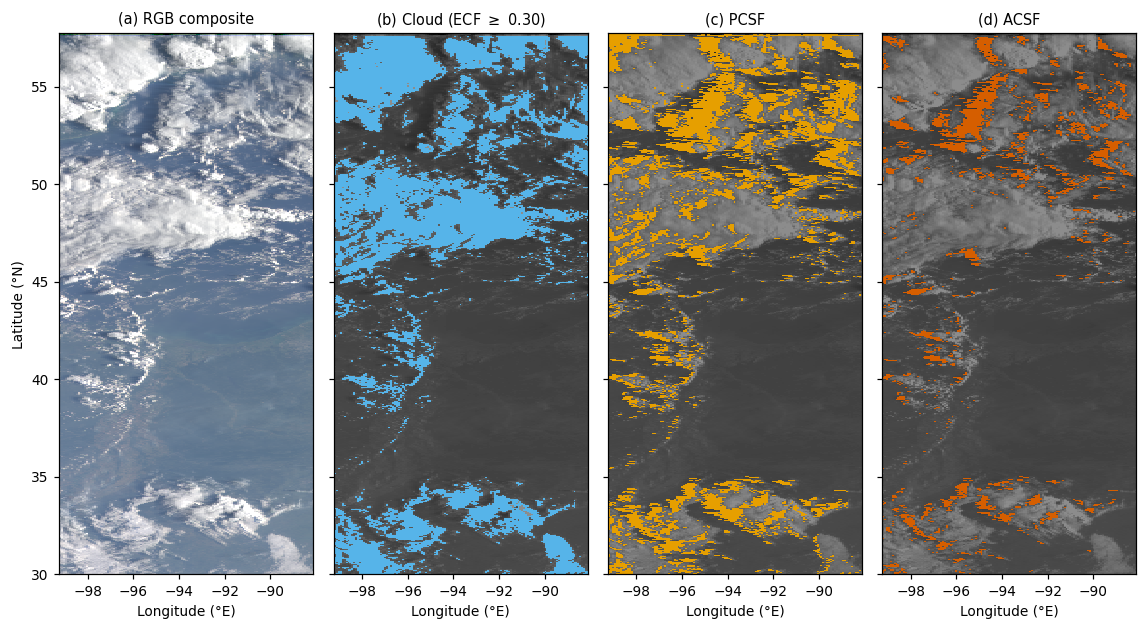

In [4]:
# Display crop for the per-granule figures: the granules contain no valid
# data in the swath-edge wedge south of ~30° N; crop affects display only.
GRANULE_LAT_MIN = 30.0


def _rgb_stack(l1: dict) -> np.ndarray:
    """(mirror_step, xtrack, 3) gamma-corrected RGB in [0, 1], NaN as black."""
    rgb = np.dstack([l1["red"], l1["green"], l1["blue"]])
    rgb = np.clip(np.nan_to_num(rgb, nan=0.0, posinf=1.0, neginf=0.0), 0.0, 1.0)
    if CFG["apply_gamma"]:
        rgb = rgb ** CFG["gamma"]
    return rgb


def plot_granule(res: dict, out_pdf: Path) -> None:
    """Four-panel granule figure: (a) RGB, (b) cloud mask, (c) PCSF, (d) ACSF.

    Masks are overlaid in full opacity on a dimmed grayscale copy of the RGB so
    the reader can relate every flag to the underlying scene. Axes are
    geographic (bounding-box approximation of the curvilinear swath, as in the
    GeoTIFF outputs).
    """
    l2 = res["l2"]
    rgb_o = np.dstack([orient_2d(_rgb_stack(res["l1"])[..., i]) for i in range(3)])
    gray = rgb_o.mean(axis=2) * 0.55
    lon_o, lat_o = orient_2d(l2["lon"]), orient_2d(l2["lat"])
    extent = [np.nanmin(lon_o), np.nanmax(lon_o), np.nanmin(lat_o), np.nanmax(lat_o)]

    panels = [
        ("(a) RGB composite", None, None),
        ("(b) Cloud (ECF $\\geq$ 0.30)", res["cloud"], C_CLOUD),
        ("(c) PCSF", res["pcsf"], C_PCSF),
        ("(d) ACSF", res["acsf"], C_ACSF),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(10.5, 5.8), sharey=True)
    for ax, (title, mask, color) in zip(axes, panels):
        if mask is None:
            ax.imshow(rgb_o, extent=extent, aspect="auto",
                      interpolation="nearest", rasterized=True)
        else:
            ax.imshow(gray, cmap="gray", vmin=0.0, vmax=1.0, extent=extent,
                      aspect="auto", interpolation="nearest", rasterized=True)
            m = orient_2d(mask)
            overlay = np.zeros(m.shape + (4,))
            overlay[..., :3] = mcolors.to_rgb(color)
            overlay[..., 3] = m.astype(float)
            ax.imshow(overlay, extent=extent, aspect="auto",
                      interpolation="nearest", rasterized=True)
        ax.set_title(title)
        ax.set_xlabel("Longitude (°E)")
    axes[0].set_ylabel("Latitude (°N)")
    axes[0].set_ylim(GRANULE_LAT_MIN, extent[3])
    fig.tight_layout()
    fig.savefig(out_pdf, bbox_inches="tight")
    print(f"wrote {out_pdf}")


plot_granule(morning,   FIG_DIR / "fig_granule_morning.pdf")
plot_granule(afternoon, FIG_DIR / "fig_granule_afternoon.pdf")

## Per-scan figure (`fig:scan-mosaic`)

Built entirely from the pipeline outputs for scan S004 of 2025-09-17 in
`results_scan_scan/2025/09/17/` (produced by `scripts/run_scan.py` with the
ECEF k-d-tree code): the merged RGB GeoTIFF plus the three polygon shapefiles.
Nothing is recomputed here.

rgb_S004.tif  raster 1181 x 2048 px   lon [-164.4, -19.7]  lat [17.2, 63.7]


S004_clouds.shp                    8305 polygons


S004_potential_shadows.shp        17198 polygons


S004_actual_shadows.shp            5970 polygons


wrote /Users/maperezc/Downloads/TEMPO/preprocess_shadows/docs/paper/figures/fig_scan_S004.pdf


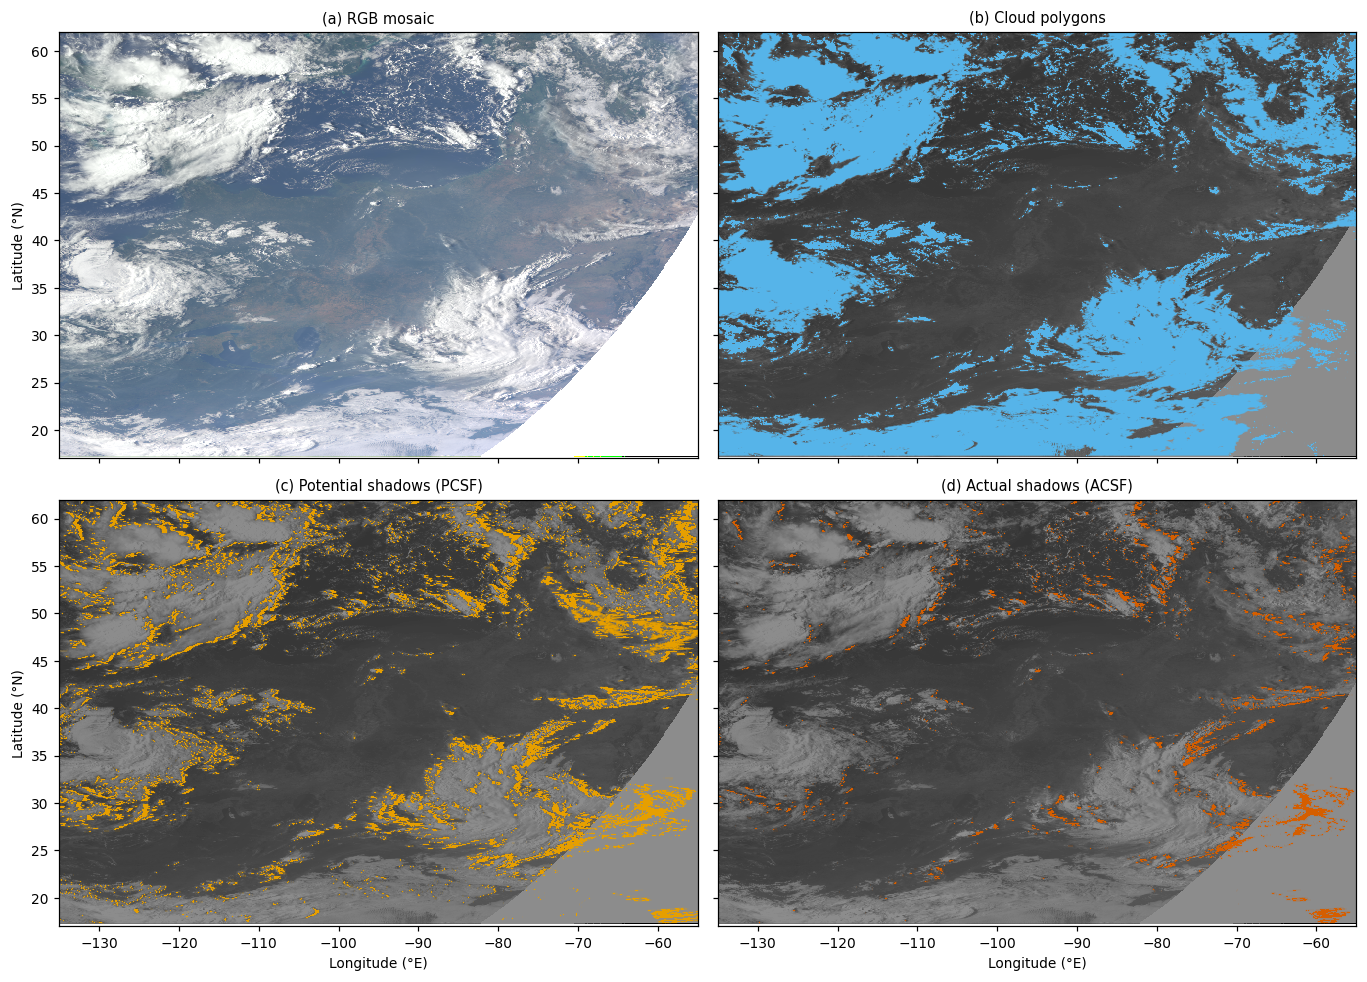

In [5]:
SCAN_DIR = REPO / "results_scan_scan" / "2025" / "09" / "17"
SCAN = "S004"

with rasterio.open(SCAN_DIR / f"rgb_{SCAN}.tif") as src:
    scan_rgb = src.read().transpose(1, 2, 0).astype(float) / 255.0
    b = src.bounds
    scan_extent = [b.left, b.right, b.bottom, b.top]
print(f"rgb_{SCAN}.tif  raster {scan_rgb.shape[1]} x {scan_rgb.shape[0]} px   "
      f"lon [{b.left:.1f}, {b.right:.1f}]  lat [{b.bottom:.1f}, {b.top:.1f}]")

layers = [
    (f"{SCAN}_clouds.shp",            C_CLOUD, "(b) Cloud polygons"),
    (f"{SCAN}_potential_shadows.shp", C_PCSF,  "(c) Potential shadows (PCSF)"),
    (f"{SCAN}_actual_shadows.shp",    C_ACSF,  "(d) Actual shadows (ACSF)"),
]

# Display crop: the bounding-box affine of the merged scan spans the extreme
# swath-edge geolocations (lon -164 to -20); the scientifically relevant field
# of regard is CONUS and surroundings. The crop affects display only.
CROP_LON = (-135.0, -55.0)
CROP_LAT = (17.0, 62.0)

scan_gray = scan_rgb.mean(axis=2) * 0.55
fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0), sharex=True, sharey=True)
axes = list(axes.flat)
axes[0].imshow(scan_rgb, extent=scan_extent, aspect="auto",
               interpolation="nearest", rasterized=True)
axes[0].set_title("(a) RGB mosaic")
for ax, (shp, color, title) in zip(axes[1:], layers):
    gdf = gpd.read_file(SCAN_DIR / shp)
    print(f"{shp:32s} {len(gdf):6d} polygons")
    ax.imshow(scan_gray, cmap="gray", vmin=0.0, vmax=1.0, extent=scan_extent,
              aspect="auto", interpolation="nearest", rasterized=True)
    gdf.plot(ax=ax, facecolor=color, edgecolor=color, linewidth=0.1, aspect=None)
    ax.set_title(title)
for ax in axes[2:]:
    ax.set_xlabel("Longitude (°E)")
for ax in (axes[0], axes[2]):
    ax.set_ylabel("Latitude (°N)")
axes[0].set_xlim(*CROP_LON)
axes[0].set_ylim(*CROP_LAT)
fig.tight_layout()
fig.savefig(FIG_DIR / f"fig_scan_{SCAN}.pdf", bbox_inches="tight")
print(f"wrote {FIG_DIR / f'fig_scan_{SCAN}.pdf'}")

## Execution record

All numbers quoted in the figure captions (mask counts, percentages, solar
azimuths) are printed by the cells above. Figures are traceable to the git
hash and configuration logged in the first code cell.